# Training-fold time-course visualization

This notebook explores only the fixed training fold. The validation and test folds remain untouched for model selection and final evaluation.

## 1. Load the training fold

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from aeon.clustering import TimeSeriesKMedoids
from IPython.display import display
from scipy.ndimage import gaussian_filter1d
from sklearn.cluster import KMeans

from deeplearning_examples.io import load_data


RANDOM_SEED = 42
N_EXAMPLE_TRAJECTORIES = 12

time_courses, doses, years = load_data("train")
time_index = np.arange(time_courses.shape[1])
metadata = pd.DataFrame({"dose": doses, "year": years})
dose_order = sorted(metadata["dose"].unique(), key=lambda value: float(value.removesuffix("pM")))
dose_colors = dict(zip(dose_order, plt.cm.viridis(np.linspace(0.08, 0.92, len(dose_order)))))

print(f"training time courses: {time_courses.shape}")
metadata.groupby(["dose", "year"]).size().unstack(fill_value=0).reindex(dose_order)

training time courses: (2790, 289)


year,2013,2014
dose,,
0pM,286,0
1pM,286,335
2.5pM,252,281
5pM,235,252
25pM,281,300
100pM,282,0


## 2. Example trajectories and population summaries

Thin lines are randomly selected training trajectories. The solid line is the class mean and the shaded region spans one standard deviation above and below it.

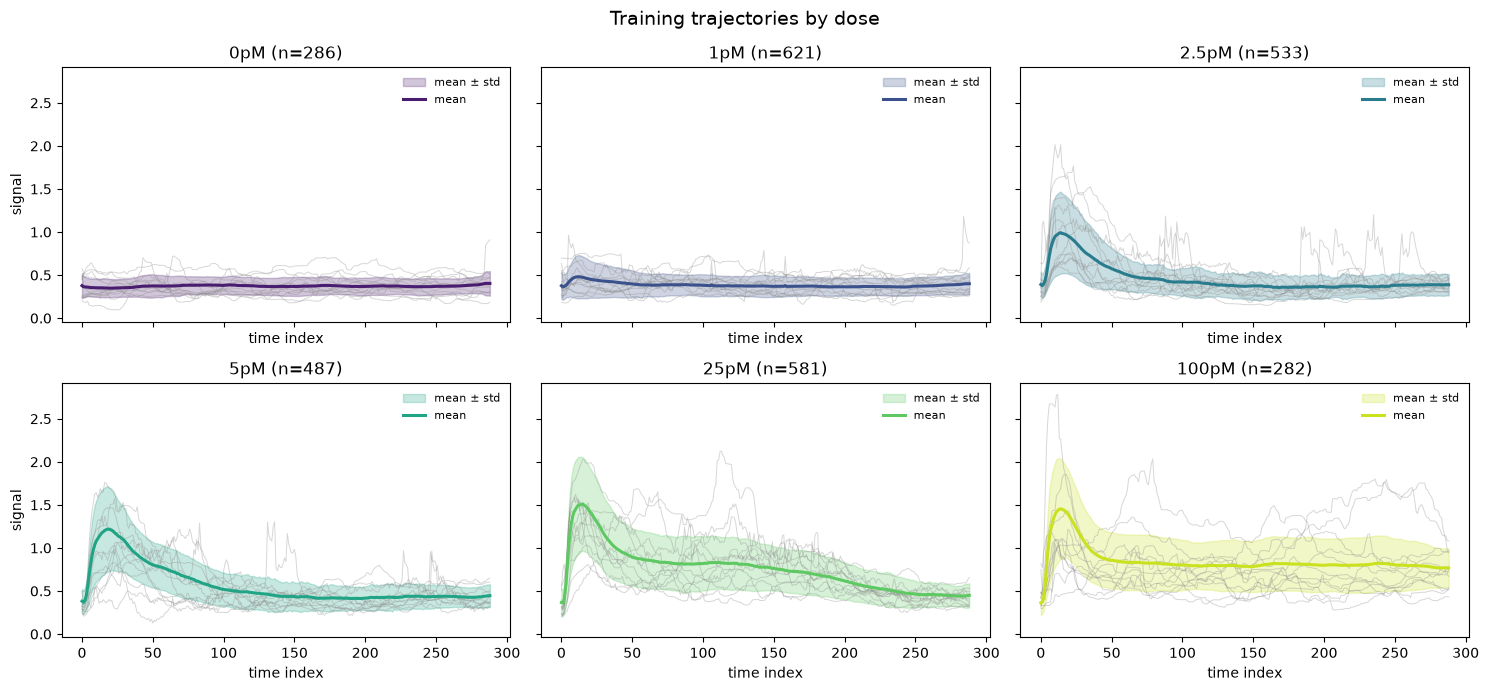

In [17]:
rng = np.random.default_rng(RANDOM_SEED)
figure, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True, sharey=True)

for dose, axis in zip(dose_order, axes.flat):
    class_indices = np.flatnonzero(doses == dose)
    selected_indices = rng.choice(
        class_indices,
        size=min(N_EXAMPLE_TRAJECTORIES, len(class_indices)),
        replace=False,
    )
    class_trajectories = time_courses[class_indices]
    mean_trajectory = class_trajectories.mean(axis=0)
    std_trajectory = class_trajectories.std(axis=0)
    color = dose_colors[dose]

    axis.plot(
        time_index,
        time_courses[selected_indices].T,
        color="0.55",
        linewidth=0.7,
        alpha=0.35,
    )
    axis.fill_between(
        time_index,
        mean_trajectory - std_trajectory,
        mean_trajectory + std_trajectory,
        color=color,
        alpha=0.25,
        label="mean ± std",
    )
    axis.plot(time_index, mean_trajectory, color=color, linewidth=2.2, label="mean")
    axis.set_title(f"{dose} (n={len(class_indices)})")
    axis.set_xlabel("time index")
    axis.legend(frameon=False, fontsize=8)

for axis in axes[:, 0]:
    axis.set_ylabel("signal")

figure.suptitle("Training trajectories by dose", fontsize=14)
figure.tight_layout()

### Interpretation

The 0 pM and 1 pM population means remain close to a low baseline, whereas doses from 2.5 pM onward show a pronounced early response. Mean signal and response amplitude increase with dose, but the response is not simply a rescaled version of one common curve: the higher-dose conditions also differ in decay and sustained activity.

The standard-deviation bands widen strongly with dose. This heteroscedasticity and the visibly diverse single-cell shapes mean that a classifier should not rely on the population mean alone.

## 3. Statistical trajectory features

The following features summarize signal level, within-trajectory variability, response magnitude and temporal change for every training cell:

- **mean signal**: average over all timepoints
- **temporal standard deviation**: variation within one trajectory
- **maximum signal** and **dynamic range**: response magnitude
- **endpoint change**: mean of the final 12 points minus the mean of the first 12
- **mean absolute step**: average absolute change between consecutive timepoints

In [18]:
feature_columns = [
    "mean signal",
    "temporal std",
    "maximum signal",
    "dynamic range",
    "endpoint change",
    "mean absolute step",
]

features = metadata.copy()
features["mean signal"] = time_courses.mean(axis=1)
features["temporal std"] = time_courses.std(axis=1)
features["maximum signal"] = time_courses.max(axis=1)
features["dynamic range"] = np.ptp(time_courses, axis=1)
features["endpoint change"] = (
    time_courses[:, -12:].mean(axis=1) - time_courses[:, :12].mean(axis=1)
)
features["mean absolute step"] = np.abs(np.diff(time_courses, axis=1)).mean(axis=1)

features.groupby("dose")[feature_columns].median().reindex(dose_order).round(3)

,mean signal,temporal std,maximum signal,dynamic range,endpoint change,mean absolute step
dose,,,,,,
0pM,0.362,0.065,0.546,0.312,0.034,0.007
1pM,0.374,0.077,0.610,0.377,0.003,0.012
2.5pM,0.447,0.185,1.145,0.924,-0.240,0.019
5pM,0.563,0.266,1.390,1.132,-0.260,0.020
25pM,0.728,0.304,1.663,1.383,-0.508,0.028
100pM,0.807,0.261,1.610,1.289,-0.107,0.019


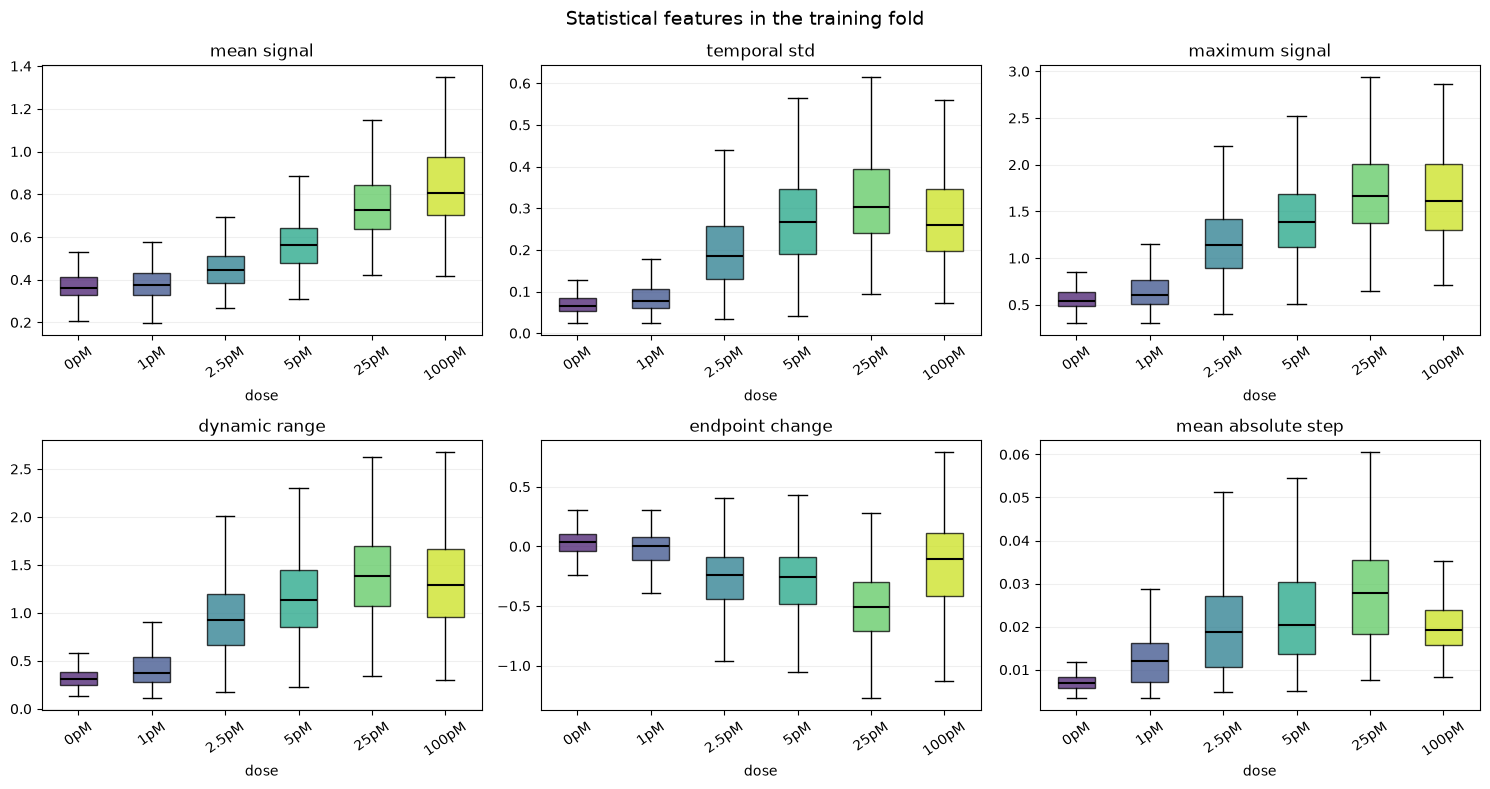

In [19]:
figure, axes = plt.subplots(2, 3, figsize=(15, 8))

for feature, axis in zip(feature_columns, axes.flat):
    values_by_dose = [
        features.loc[features["dose"] == dose, feature].to_numpy()
        for dose in dose_order
    ]
    boxplot = axis.boxplot(
        values_by_dose,
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "black", "linewidth": 1.5},
    )
    for patch, dose in zip(boxplot["boxes"], dose_order):
        patch.set_facecolor(dose_colors[dose])
        patch.set_alpha(0.75)
    axis.set_title(feature)
    axis.set_xlabel("dose")
    axis.set_xticks(range(1, len(dose_order) + 1), dose_order)
    axis.tick_params(axis="x", rotation=35)
    axis.grid(axis="y", alpha=0.2)

figure.suptitle("Statistical features in the training fold", fontsize=14)
figure.tight_layout()

### Interpretation

Mean signal, maximum and dynamic range separate low from high doses particularly well. Temporal variability and mean absolute step also rise with dose, showing that response dynamics contain information beyond the overall signal level. The broad, overlapping boxes nevertheless rule out a reliable classifier based on a single summary feature.

Endpoint change is mostly negative for the responding doses because the early peak decays. Its different distribution at 100 pM suggests that temporal order can help distinguish trajectories with otherwise similar amplitudes.

### Feature correlations

The correlation matrix highlights redundant summaries before they are considered as model inputs.

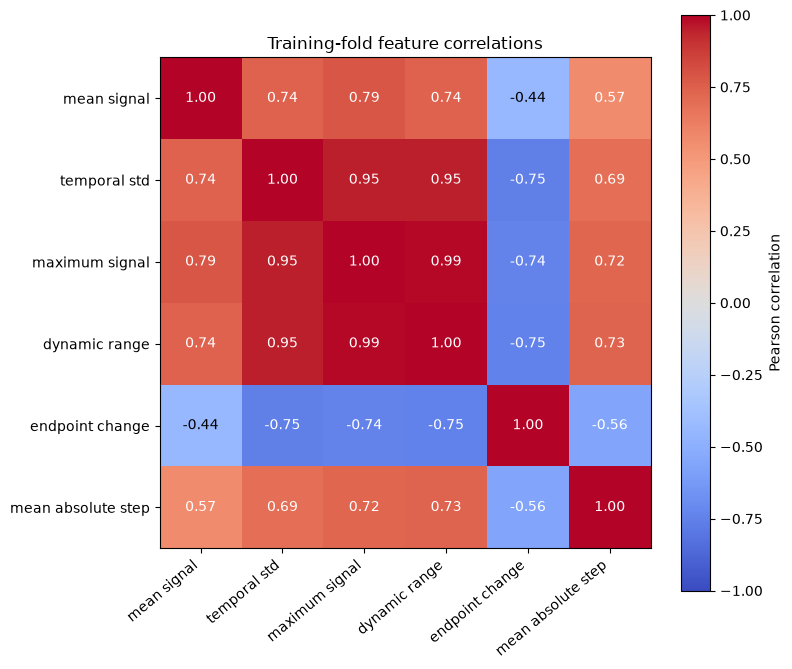

In [20]:
correlations = features[feature_columns].corr()
figure, axis = plt.subplots(figsize=(8, 7))
image = axis.imshow(correlations, vmin=-1, vmax=1, cmap="coolwarm")
axis.set_xticks(range(len(feature_columns)), feature_columns, rotation=40, ha="right")
axis.set_yticks(range(len(feature_columns)), feature_columns)

for row in range(len(feature_columns)):
    for column in range(len(feature_columns)):
        value = correlations.iloc[row, column]
        text_color = "white" if abs(value) > 0.55 else "black"
        axis.text(column, row, f"{value:.2f}", ha="center", va="center", color=text_color)

figure.colorbar(image, ax=axis, label="Pearson correlation")
axis.set_title("Training-fold feature correlations")
figure.tight_layout()

## 4. Dose-independent trajectory clustering

The trajectories are clustered without giving the algorithm dose or year labels. Three complementary representations are compared: TWED for slightly time-shifted shapes, FFT magnitudes for frequency content, and autocorrelation for recurring temporal structure. **There is deliberately no amplitude standardization or per-trajectory normalization:** absolute signal level and response magnitude are strongly dose-dependent and must remain visible to every clustering method.

### 4.1 TWED clustering

A light Gaussian smoothing suppresses frame-to-frame measurement noise. The smoothed curves are downsampled uniformly to make the elastic distance computationally tractable. No centering is applied to the TWED input.

Time Warp Edit Distance (TWED, called `twe` in aeon) compares signal values and local changes while allowing limited edits along the time axis. Its stiffness, edit penalty and warping window prevent arbitrary alignment. K-medoids is used instead of K-means because elastic distances do not have a meaningful arithmetic mean; every cluster is represented by a real training trajectory. Six clusters are used as an explicit exploratory resolution, not inferred from the six dose labels. Dose and year are inspected only after assignments have been fixed.

In [7]:
TWE_DOWNSAMPLE_STRIDE = 4
TWE_WINDOW = 0.05
TWE_STIFFNESS = 0.001
TWE_EDIT_PENALTY = 1.0
TWE_CLUSTER_COUNT = 6

smoothed_time_courses = gaussian_filter1d(time_courses, sigma=2.0, axis=1)
twed_time_courses = np.ascontiguousarray(
    smoothed_time_courses[:, ::TWE_DOWNSAMPLE_STRIDE], dtype=np.float64,
)
twed_time_index = time_index[::TWE_DOWNSAMPLE_STRIDE]

print(f"TWED input shape: {twed_time_courses.shape}")
print(
    "Amplitude range retained: "
    f"{twed_time_courses.min():.3f} to {twed_time_courses.max():.3f}"
)
assert np.allclose(
    twed_time_courses, smoothed_time_courses[:, ::TWE_DOWNSAMPLE_STRIDE]
), "TWED input must not be amplitude-normalized"

TWED input shape: (2790, 73)
Amplitude range retained: 0.056 to 3.899


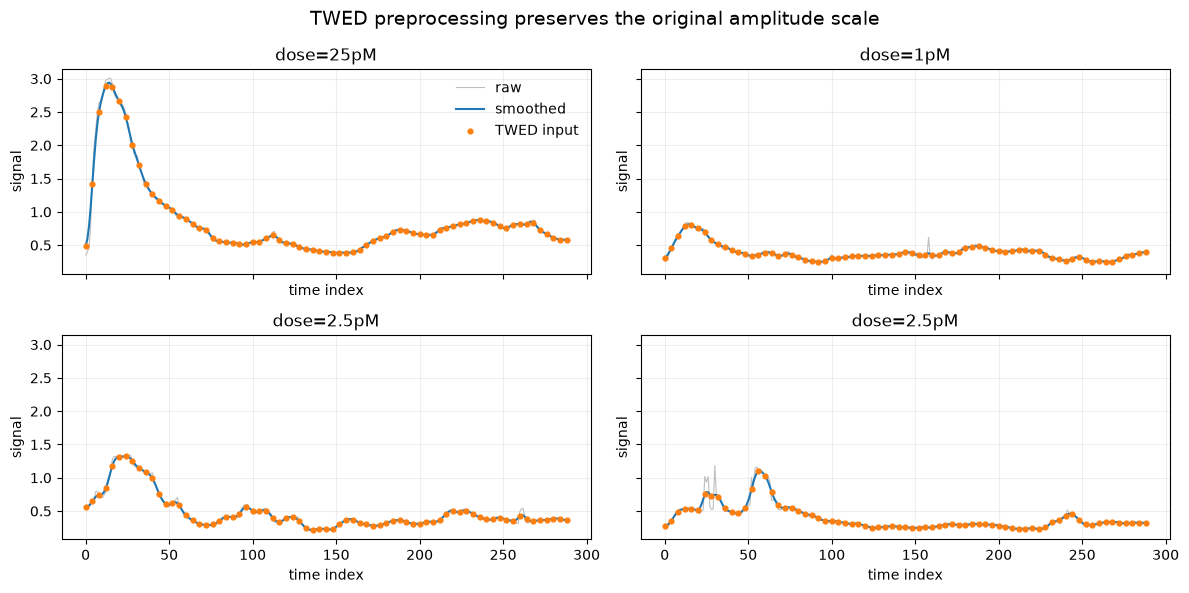

In [8]:
preview_rng = np.random.default_rng(RANDOM_SEED)
preview_indices = preview_rng.choice(len(time_courses), size=4, replace=False)
figure, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True, sharey=True)
for axis, index in zip(axes.flat, preview_indices):
    axis.plot(time_index, time_courses[index], color="0.75", linewidth=0.8, label="raw")
    axis.plot(time_index, smoothed_time_courses[index], color="tab:blue", label="smoothed")
    axis.scatter(
        twed_time_index, twed_time_courses[index],
        color="tab:orange", s=12, zorder=3, label="TWED input",
    )
    axis.set(title=f"dose={doses[index]}", xlabel="time index", ylabel="signal")
    axis.grid(alpha=0.2)
axes[0, 0].legend(frameon=False)
figure.suptitle("TWED preprocessing preserves the original amplitude scale", fontsize=14)
figure.tight_layout()

### TWED configuration and K-medoids clustering

`window=0.05` restricts alignment to a small neighborhood around the original time, `nu` controls temporal stiffness and `lmbda` penalizes edit operations. These parameters should be treated as modeling assumptions and checked in a sensitivity analysis. The faster alternating K-medoids update is used because full PAM is prohibitively expensive for 2,790 trajectories. Multiple initializations reduce sensitivity to the first medoids.

In [9]:
selected_cluster_count = TWE_CLUSTER_COUNT
cluster_model = TimeSeriesKMedoids(
    n_clusters=selected_cluster_count,
    init="random",
    distance="twe",
    distance_params={
        "window": TWE_WINDOW,
        "nu": TWE_STIFFNESS,
        "lmbda": TWE_EDIT_PENALTY,
    },
    method="alternate",
    n_init=3,
    max_iter=30,
    random_state=RANDOM_SEED,
)
raw_cluster_labels = cluster_model.fit_predict(twed_time_courses)

# Give low-mean clusters the smaller, reproducible display numbers.
cluster_order = np.argsort([
    time_courses[raw_cluster_labels == cluster].mean()
    for cluster in range(selected_cluster_count)
])
cluster_label_map = {
    old_label: new_label for new_label, old_label in enumerate(cluster_order)
}
cluster_labels = np.array([cluster_label_map[label] for label in raw_cluster_labels])
cluster_names = [f"Cluster {cluster + 1}" for cluster in range(selected_cluster_count)]
metadata["cluster"] = pd.Categorical(
    [cluster_names[label] for label in cluster_labels],
    categories=cluster_names, ordered=True,
)

print(
    f"TWED K-medoids: {selected_cluster_count} clusters, "
    f"{cluster_model.n_iter_} iterations, inertia={cluster_model.inertia_:.2f}"
)

TWED K-medoids: 6 clusters, 7 iterations, inertia=49920.39


### Cluster trajectory profiles

The profiles below use the original, unstandardized signal scale. Thin lines show a reproducible sample of individual cells; the solid line and band show the cluster mean and one standard deviation. Orange markers identify the actual medoid used by TWED after smoothing and downsampling. Unlike a centroid, this representative is an observed training trajectory.

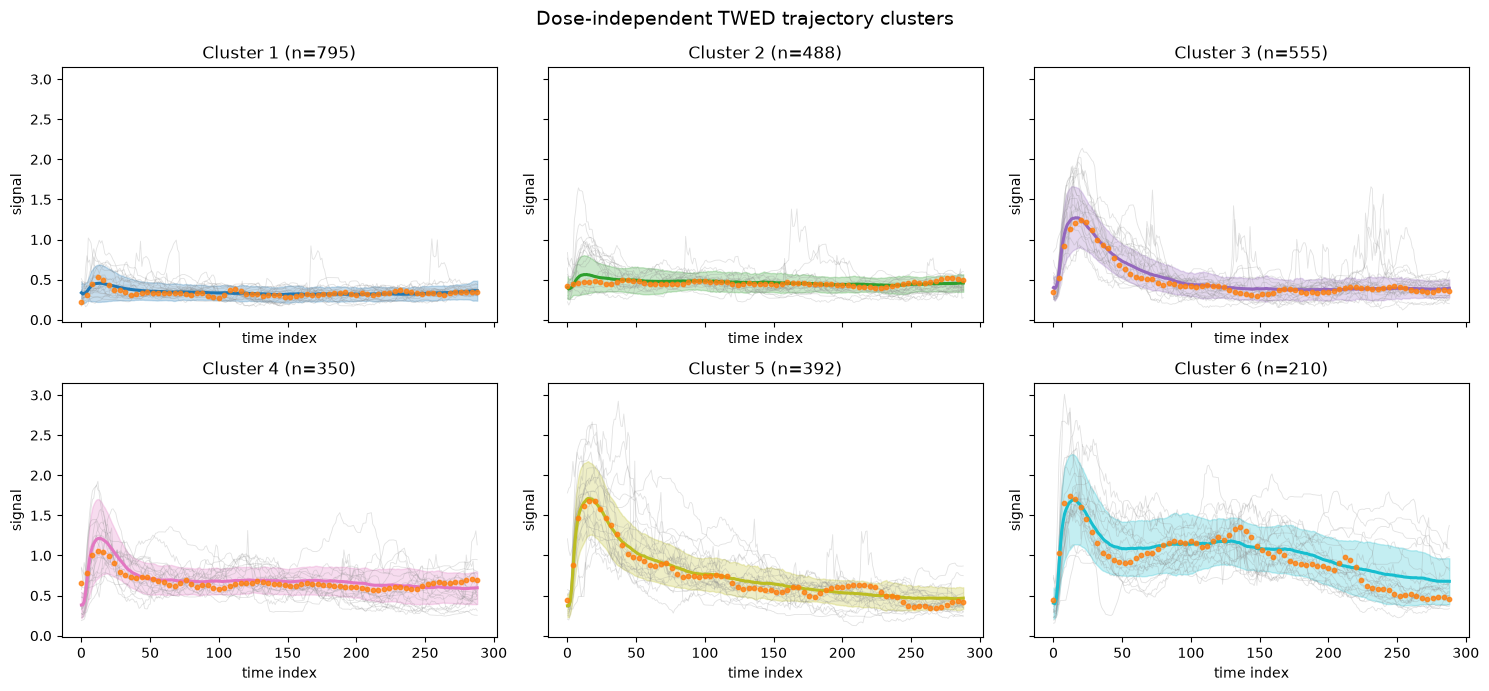

In [10]:
cluster_columns = min(3, selected_cluster_count)
cluster_rows = int(np.ceil(selected_cluster_count / cluster_columns))
figure, axes = plt.subplots(
    cluster_rows, cluster_columns, figsize=(5 * cluster_columns, 3.5 * cluster_rows),
    sharex=True, sharey=True, squeeze=False,
)
cluster_colors = plt.cm.tab10(np.linspace(0, 1, selected_cluster_count))
cluster_rng = np.random.default_rng(RANDOM_SEED)

for cluster, (axis, color) in enumerate(zip(axes.flat, cluster_colors)):
    cluster_indices = np.flatnonzero(cluster_labels == cluster)
    selected_indices = cluster_rng.choice(
        cluster_indices, size=min(20, len(cluster_indices)), replace=False,
    )
    cluster_trajectories = time_courses[cluster_indices]
    cluster_mean = cluster_trajectories.mean(axis=0)
    cluster_std = cluster_trajectories.std(axis=0)
    axis.plot(
        time_index, time_courses[selected_indices].T,
        color="0.55", linewidth=0.6, alpha=0.25,
    )
    axis.fill_between(
        time_index, cluster_mean - cluster_std, cluster_mean + cluster_std,
        color=color, alpha=0.25,
    )
    axis.plot(time_index, cluster_mean, color=color, linewidth=2.2)
    raw_cluster = cluster_order[cluster]
    cluster_medoid = np.asarray(cluster_model.cluster_centers_[raw_cluster]).squeeze()
    axis.scatter(
        twed_time_index, cluster_medoid,
        color="tab:orange", s=10, alpha=0.8, label="TWED medoid", zorder=3,
    )
    axis.set_title(f"{cluster_names[cluster]} (n={len(cluster_indices)})")
    axis.set_xlabel("time index")
    axis.set_ylabel("signal")

for axis in axes.flat[selected_cluster_count:]:
    axis.set_visible(False)
figure.suptitle("Dose-independent TWED trajectory clusters", fontsize=14)
figure.tight_layout()

### Cluster frequency by dose

Absolute counts retain information about the unequal number of cells per dose. Within-dose percentages answer the complementary question: for a cell from a given dose, how likely is each trajectory cluster?

Cluster counts per dose:


cluster,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6
dose,,,,,,
0pM,184,99,1,2,0,0
1pM,377,199,33,8,3,1
2.5pM,189,82,220,21,21,0
5pM,43,56,249,43,94,2
25pM,1,43,39,139,239,120
100pM,1,9,13,137,35,87


Within-dose cluster percentages:


cluster,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6
dose,,,,,,
0pM,64.3,34.6,0.3,0.7,0.0,0.0
1pM,60.7,32.0,5.3,1.3,0.5,0.2
2.5pM,35.5,15.4,41.3,3.9,3.9,0.0
5pM,8.8,11.5,51.1,8.8,19.3,0.4
25pM,0.2,7.4,6.7,23.9,41.1,20.7
100pM,0.4,3.2,4.6,48.6,12.4,30.9


Within-year cluster percentages (confounding check):


cluster,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6
year,,,,,,
2013,30.0,17.8,16.0,14.5,12.4,9.2
2014,26.4,17.0,25.3,9.8,16.4,5.1


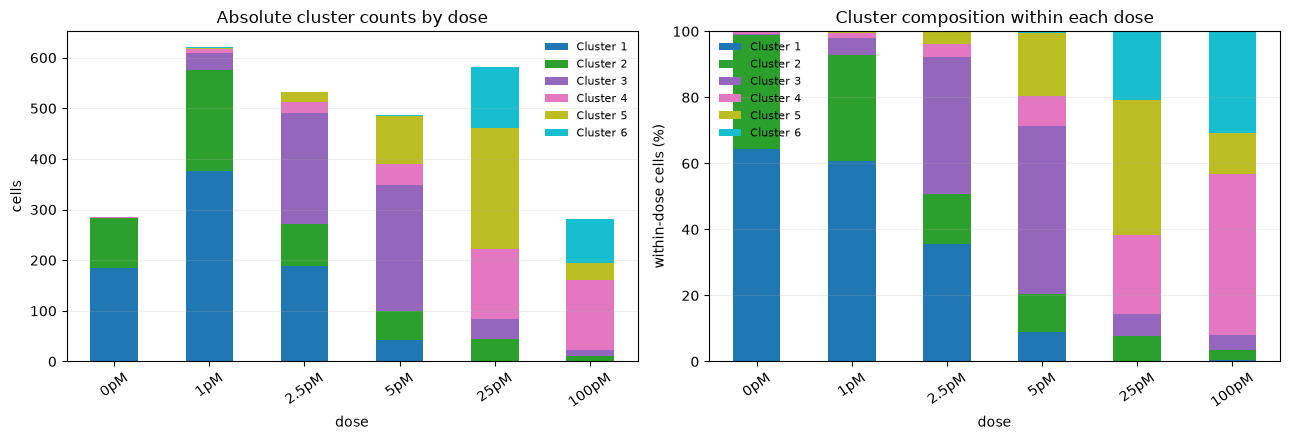

In [11]:
cluster_by_dose_count = pd.crosstab(
    pd.Categorical(metadata["dose"], categories=dose_order, ordered=True),
    metadata["cluster"],
).reindex(index=dose_order, columns=cluster_names, fill_value=0)
cluster_by_dose_count.index.name = "dose"
cluster_by_dose_count.columns.name = "cluster"
cluster_by_dose_percent = (
    cluster_by_dose_count.div(cluster_by_dose_count.sum(axis=1), axis=0) * 100
)
cluster_by_year_percent = (
    pd.crosstab(metadata["year"], metadata["cluster"], normalize="index")
    .reindex(columns=cluster_names, fill_value=0) * 100
)

print("Cluster counts per dose:")
display(cluster_by_dose_count)
print("Within-dose cluster percentages:")
display(cluster_by_dose_percent.round(1))
print("Within-year cluster percentages (confounding check):")
display(cluster_by_year_percent.round(1))

figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))
cluster_by_dose_count.plot.bar(
    stacked=True, ax=axes[0], color=cluster_colors, rot=35,
)
axes[0].set(title="Absolute cluster counts by dose", xlabel="dose", ylabel="cells")
cluster_by_dose_percent.plot.bar(
    stacked=True, ax=axes[1], color=cluster_colors, rot=35, ylim=(0, 100),
)
axes[1].set(
    title="Cluster composition within each dose",
    xlabel="dose", ylabel="within-dose cells (%)",
)
for axis in axes:
    axis.grid(axis="y", alpha=0.2)
    axis.legend(frameon=False, fontsize=8)
figure.tight_layout()

### Interpretation

The six TWED clusters are ordered by their mean signal on the original scale, so lower display numbers correspond to lower-amplitude response states. Assignment itself uses the raw-amplitude TWED representation: it can tolerate a limited temporal displacement, but it cannot remove an amplitude difference through normalization.

The dose tables should be read as population mixtures rather than predicted labels. A gradual redistribution from lower- to higher-amplitude clusters would indicate dose-dependent response states, while multiple clusters within one dose can reveal kinetic heterogeneity that a class mean hides. The medoids make it possible to distinguish a genuine timing motif from a broad cluster caused only by amplitude.

On the current training fold, this redistribution is pronounced. The two lowest-response clusters contain 98.9% of 0 pM and 92.7% of 1 pM cells. Cluster 3 becomes dominant at 2.5 pM (41.3%) and 5 pM (51.1%). At 25 pM, Clusters 4–6 contain 85.7% of cells; at 100 pM they contain 91.9%. The different mixtures at 25 and 100 pM—especially Cluster 5 versus Clusters 4 and 6—suggest that TWED retains kinetic distinctions beyond a single amplitude ordering.

Year composition is not constant: for example, Cluster 3 contains 16.0% of 2013 but 25.3% of 2014 cells, whereas Cluster 6 contains 9.2% versus 5.1%. This does not invalidate the clusters, but it prevents a purely dose-driven biological interpretation because acquisition year and dose are partially confounded.

The year-wise composition remains an essential confounding check. In addition, conclusions should be stable under reasonable changes to `window`, `nu`, `lmbda`, downsampling stride and initialization. The six-cluster resolution is exploratory and must not be interpreted as evidence that exactly six biological states exist.

### 4.2 FFT clustering

The real FFT decomposes each smoothed trajectory into a constant component and oscillations at increasing frequencies. Clustering the magnitudes makes the representation insensitive to phase: two oscillations with the same frequency but a modest temporal offset can therefore remain close. The DC component is retained, and the spectrum is only divided by the common sequence length. There is **no per-trajectory normalization, logarithmic compression, or feature standardization**, so absolute signal amplitude still contributes directly. The trade-off is that FFT magnitudes discard the precise position of a peak.

In [12]:
FEATURE_CLUSTER_COUNT = 6
FFT_COMPONENT_COUNT = 48
AUTOCORR_MAX_LAG = 72

def order_labels_by_original_amplitude(raw_labels):
    raw_order = np.argsort([
        time_courses[raw_labels == cluster].mean()
        for cluster in range(FEATURE_CLUSTER_COUNT)
    ])
    label_map = {old: new for new, old in enumerate(raw_order)}
    return np.array([label_map[label] for label in raw_labels])


def summarize_feature_clusters(labels, method_name):
    names = [f"Cluster {index + 1}" for index in range(FEATURE_CLUSTER_COUNT)]
    categorical_labels = pd.Categorical(
        [names[label] for label in labels], categories=names, ordered=True,
    )
    counts = pd.crosstab(
        pd.Categorical(metadata["dose"], categories=dose_order, ordered=True),
        categorical_labels,
    ).reindex(index=dose_order, columns=names, fill_value=0)
    counts.index.name = "dose"
    counts.columns.name = "cluster"
    percentages = counts.div(counts.sum(axis=1), axis=0) * 100
    year_percentages = (
        pd.crosstab(metadata["year"], categorical_labels, normalize="index")
        .reindex(columns=names, fill_value=0) * 100
    )

    print(f"{method_name} cluster counts per dose:")
    display(counts)
    print(f"{method_name} within-dose percentages:")
    display(percentages.round(1))
    print(f"{method_name} within-year percentages (confounding check):")
    display(year_percentages.round(1))

    figure, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True, sharey=True)
    rng = np.random.default_rng(RANDOM_SEED)
    for cluster, (axis, color) in enumerate(zip(axes.flat, cluster_colors)):
        indices = np.flatnonzero(labels == cluster)
        selected = rng.choice(indices, size=min(20, len(indices)), replace=False)
        trajectories = time_courses[indices]
        mean = trajectories.mean(axis=0)
        std = trajectories.std(axis=0)
        axis.plot(time_index, time_courses[selected].T, color="0.55", linewidth=0.5, alpha=0.2)
        axis.fill_between(time_index, mean - std, mean + std, color=color, alpha=0.25)
        axis.plot(time_index, mean, color=color, linewidth=2.2)
        axis.set(title=f"{names[cluster]} (n={len(indices)})", xlabel="time index", ylabel="signal")
    figure.suptitle(f"{method_name} clusters on the original amplitude scale", fontsize=14)
    figure.tight_layout()

    axis = percentages.plot.bar(
        stacked=True, figsize=(8, 4), color=cluster_colors, rot=35, ylim=(0, 100),
    )
    axis.set(
        title=f"{method_name}: cluster composition within each dose",
        xlabel="dose", ylabel="within-dose cells (%)",
    )
    axis.grid(axis="y", alpha=0.2)
    axis.legend(frameon=False, fontsize=8)
    return counts, percentages


FFT feature shape: (2790, 48)
FFT DC/amplitude range retained: 0.198 to 1.760
FFT cluster counts per dose:


cluster,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6
dose,,,,,,
0pM,267,18,1,0,0,0
1pM,527,80,9,4,0,1
2.5pM,179,248,82,5,19,0
5pM,50,188,172,44,33,0
25pM,6,96,109,225,105,40
100pM,1,34,16,134,25,72


FFT within-dose percentages:


cluster,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6
dose,,,,,,
0pM,93.4,6.3,0.3,0.0,0.0,0.0
1pM,84.9,12.9,1.4,0.6,0.0,0.2
2.5pM,33.6,46.5,15.4,0.9,3.6,0.0
5pM,10.3,38.6,35.3,9.0,6.8,0.0
25pM,1.0,16.5,18.8,38.7,18.1,6.9
100pM,0.4,12.1,5.7,47.5,8.9,25.5


FFT within-year percentages (confounding check):


col_0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6
year,,,,,,
2013,41.1,18.8,12.4,15.8,6.1,5.8
2014,31.2,30.7,16.1,13.3,7.1,1.6


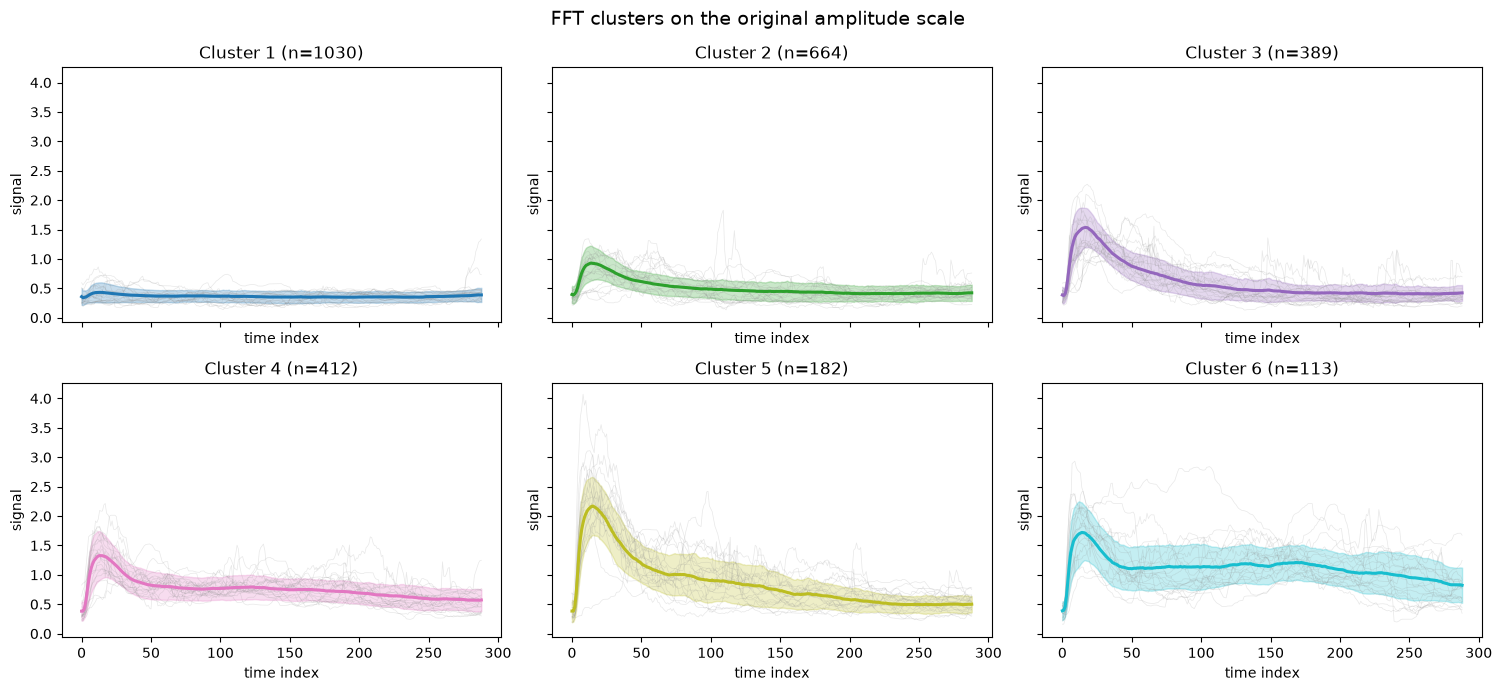

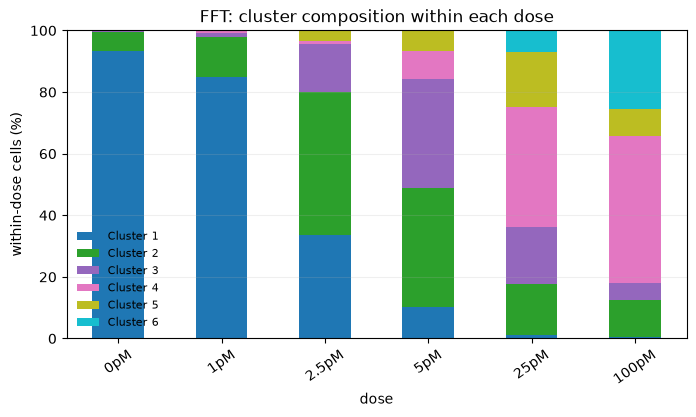

In [15]:
fft_features = np.abs(np.fft.rfft(smoothed_time_courses, axis=1))
fft_features /= smoothed_time_courses.shape[1]
fft_features[:, 1:-1] *= 2.0
fft_features = np.ascontiguousarray(fft_features[:, :FFT_COMPONENT_COUNT])

fft_cluster_model = KMeans(
    n_clusters=FEATURE_CLUSTER_COUNT, n_init=20, random_state=RANDOM_SEED,
)
fft_cluster_labels = order_labels_by_original_amplitude(
    fft_cluster_model.fit_predict(fft_features)
)
metadata["fft_cluster"] = fft_cluster_labels + 1

print(f"FFT feature shape: {fft_features.shape}")
print(
    "FFT DC/amplitude range retained: "
    f"{fft_features[:, 0].min():.3f} to {fft_features[:, 0].max():.3f}"
)
fft_cluster_counts, fft_cluster_percent = summarize_feature_clusters(
    fft_cluster_labels, "FFT",
)

### 4.3 Autocorrelation clustering

Autocorrelation compares a trajectory with delayed copies of itself. It describes how quickly temporal structure decays and whether patterns repeat, while being less sensitive to the absolute time at which a motif occurs. Here the correlation is intentionally **not centered and not divided by the trajectory variance or lag-zero energy**. Consequently lag zero retains total signal energy and the other lags retain both baseline and amplitude information. Division by the common sequence length only makes values independent of the number of recorded frames; it does not equalize trajectories.

Autocorrelation feature shape: (2790, 73)
Lag-zero energy range retained: 0.040 to 3.550
Autocorrelation cluster counts per dose:


cluster,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6
dose,,,,,,
0pM,264,22,0,0,0,0
1pM,556,61,3,1,0,0
2.5pM,360,150,21,2,0,0
5pM,129,256,91,9,2,0
25pM,10,176,247,113,33,2
100pM,5,53,111,65,47,1


Autocorrelation within-dose percentages:


cluster,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6
dose,,,,,,
0pM,92.3,7.7,0.0,0.0,0.0,0.0
1pM,89.5,9.8,0.5,0.2,0.0,0.0
2.5pM,67.5,28.1,3.9,0.4,0.0,0.0
5pM,26.5,52.6,18.7,1.8,0.4,0.0
25pM,1.7,30.3,42.5,19.4,5.7,0.3
100pM,1.8,18.8,39.4,23.0,16.7,0.4


Autocorrelation within-year percentages (confounding check):


col_0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6
year,,,,,,
2013,48.4,22.3,17.3,7.7,4.2,0.1
2014,46.1,30.6,16.4,5.6,1.2,0.1


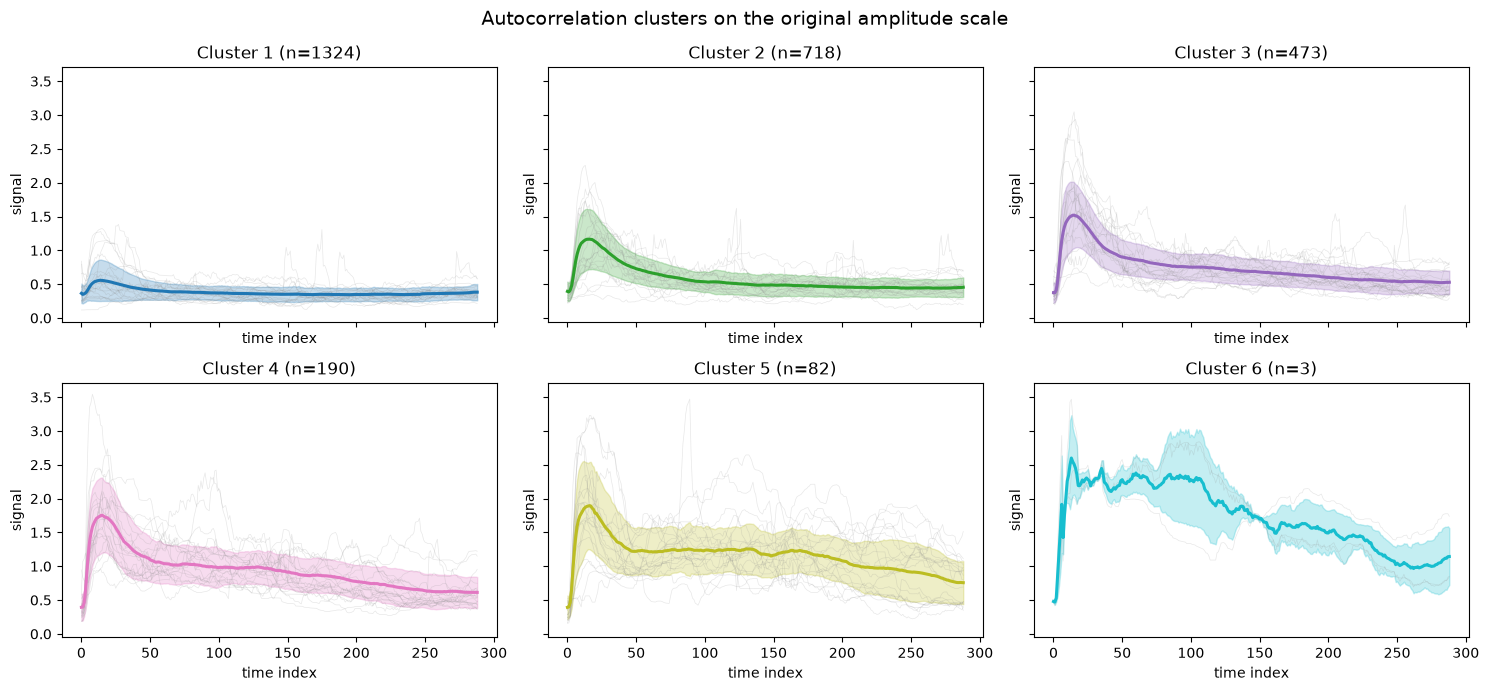

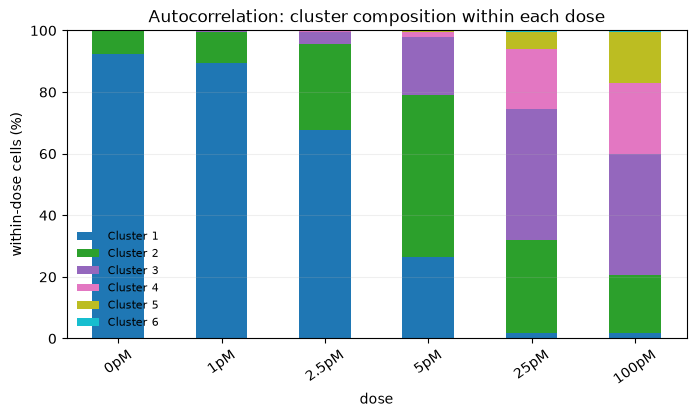

In [16]:
def amplitude_preserving_autocorrelation(trajectories, max_lag):
    sequence_length = trajectories.shape[1]
    fft_length = 1 << (2 * sequence_length - 1).bit_length()
    spectrum = np.fft.rfft(trajectories, n=fft_length, axis=1)
    correlation = np.fft.irfft(
        spectrum * spectrum.conj(), n=fft_length, axis=1,
    )[:, :max_lag + 1]
    return np.ascontiguousarray(correlation.real / sequence_length)


autocorrelation_features = amplitude_preserving_autocorrelation(
    smoothed_time_courses, AUTOCORR_MAX_LAG,
)
autocorr_cluster_model = KMeans(
    n_clusters=FEATURE_CLUSTER_COUNT, n_init=20, random_state=RANDOM_SEED,
)
autocorr_cluster_labels = order_labels_by_original_amplitude(
    autocorr_cluster_model.fit_predict(autocorrelation_features)
)
metadata["autocorrelation_cluster"] = autocorr_cluster_labels + 1

print(f"Autocorrelation feature shape: {autocorrelation_features.shape}")
print(
    "Lag-zero energy range retained: "
    f"{autocorrelation_features[:, 0].min():.3f} to "
    f"{autocorrelation_features[:, 0].max():.3f}"
)
autocorr_cluster_counts, autocorr_cluster_percent = summarize_feature_clusters(
    autocorr_cluster_labels, "Autocorrelation",
)

### Comparing the three clustering views

The methods answer different questions. TWED emphasizes pointwise shape while tolerating small temporal displacement. FFT emphasizes how much slow and fast variation a trajectory contains but discards phase. Autocorrelation emphasizes persistence and recurrence without requiring a motif at a fixed time. Agreement of dose-dependent redistribution across all three representations is stronger evidence than any one clustering alone; disagreement identifies whether a separation depends primarily on event timing, frequency composition, or persistence.

On the current training fold, both added representations show a clear dose-dependent redistribution. In the FFT view, 93.4% of 0 pM trajectories are in the lowest-amplitude cluster, while 72.3% of 100 pM trajectories are in Clusters 4–6. In the autocorrelation view, 92.3% of 0 pM trajectories are in Cluster 1, whereas 79.5% of 100 pM trajectories are in Clusters 3–6. The agreement with TWED indicates that the dose signal is visible not only in pointwise curve similarity, but also in spectral power and temporal persistence.

All three analyses retain amplitude, but this also means that amplitude can dominate subtler kinetic differences. This is especially visible for the raw autocorrelation: its sixth cluster contains only three very high-energy trajectories. That is not necessarily a biological state; it may be an outlier group induced by the squared amplitude scale of autocorrelation. Keeping it visible is preferable to silently removing dose information, but cluster size and representative trajectories must be inspected before interpretation.

Amplitude retention is intentional for this dataset because amplitude is biologically dose-dependent. A useful sensitivity analysis would cluster a second, explicitly shape-only representation and compare it to these primary amplitude-preserving results—not replace them. Cluster numbers are ordered separately by mean original amplitude and therefore do not denote matching clusters across methods. The within-year tables remain necessary because acquisition year and dose are partially confounded.

## 5. Consequences for modeling

The exploratory results motivate models that use both absolute signal and temporal structure. A CNN can detect local peaks and decay patterns, while self-attention can relate distant parts of a trajectory; positional encoding is essential for attention because the order of the 289 measurements carries biological meaning. A feature-only baseline remains useful to quantify how much the sequence models gain beyond simple amplitude statistics.

Normalization must be fitted on the training fold and applied globally. Normalizing every trajectory independently would remove much of the dose-dependent amplitude signal visible above. The cluster mixture additionally suggests that predictions should remain probabilistic: ambiguous cells near a response-state boundary should not be expected to receive perfectly separated class probabilities. Because the dose classes are imbalanced, model comparison should include macro-averaged precision, recall and F1 as well as the confusion matrix.

There is also an important limitation: 0 pM and 100 pM occur only in 2013, so dose and acquisition year are partly confounded. In addition, the labels contain no experiment or replicate identifier, meaning that a cell-level split cannot prevent correlated cells from the same experiment entering different folds. Test performance should therefore be interpreted as within-dataset discrimination, not yet as evidence of generalization to a new experiment or year.